In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

print("Imports successful.")

Imports successful.


In [2]:
ROOT = Path.cwd()

DATASET_DIR = ROOT / "results" / "datasets"
FIGURE_DIR = ROOT / "results" / "figures"
SUMMARY_DIR = ROOT / "results" / "summary"

for directory in (DATASET_DIR, FIGURE_DIR, SUMMARY_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# ============================================================
# BASELINE BOOST CONVERTER PARAMETERS
# ============================================================

VIN = 5.0
VF = 0.7

BASE_FREQUENCY = 100_000       # 100 kHz
BASE_DUTY = 0.35               # 35%

BASE_L = 100e-6                # 100 uH
BASE_C = 220e-6                # 220 uF

BASE_RLOAD = 24.0              # simulation baseline
HARDWARE_RLOAD = 27.0          # actual hardware load

BASE_SIMULATION_TIME = 0.05    # 50 ms
BASE_DT = 100e-9               # 100 ns

print("Project folders created:")
print(ROOT)

print("\nBaseline parameters:")
print(f"Input voltage       : {VIN} V")
print(f"Switching frequency : {BASE_FREQUENCY/1000:.0f} kHz")
print(f"Duty cycle          : {BASE_DUTY*100:.0f} %")
print(f"Inductor            : {BASE_L*1e6:.0f} uH")
print(f"Capacitor           : {BASE_C*1e6:.0f} uF")
print(f"Simulation load     : {BASE_RLOAD:.0f} ohm")
print(f"Hardware load       : {HARDWARE_RLOAD:.0f} ohm")
print(f"Simulation time     : {BASE_SIMULATION_TIME*1000:.0f} ms")
print(f"Time step           : {BASE_DT*1e9:.0f} ns")

Project folders created:
C:\Users\R N V SAI NANDAN\BOOST_SIMULATIONS_FINAL

Baseline parameters:
Input voltage       : 5.0 V
Switching frequency : 100 kHz
Duty cycle          : 35 %
Inductor            : 100 uH
Capacitor           : 220 uF
Simulation load     : 24 ohm
Hardware load       : 27 ohm
Simulation time     : 50 ms
Time step           : 100 ns


In [3]:
def simulate_boost(
    vin=VIN,
    vf=VF,
    frequency=BASE_FREQUENCY,
    duty=BASE_DUTY,
    inductance=BASE_L,
    capacitance=BASE_C,
    load_resistance=BASE_RLOAD,
    simulation_time=BASE_SIMULATION_TIME,
    dt=BASE_DT
):

    period = 1.0 / frequency
    ton = duty * period

    n_samples = int(simulation_time / dt)
    time = np.arange(n_samples) * dt

    # Allocate arrays
    gate = np.zeros(n_samples)
    inductor_current = np.zeros(n_samples)
    output_voltage = np.zeros(n_samples)
    switching_voltage = np.zeros(n_samples)
    diode_current = np.zeros(n_samples)
    load_current = np.zeros(n_samples)

    # Initial conditions
    iL = 0.0
    vo = 0.0

    # Time-domain simulation
    for k, current_time in enumerate(time):

        position = current_time % period

        mosfet_on = position < ton

        # ====================================================
        # MOSFET ON
        # ====================================================
        if mosfet_on:

            gate_value = 5.0

            diL_dt = vin / inductance

            dvo_dt = (
                -vo /
                (load_resistance * capacitance)
            )

            switch_voltage = 0.0
            diode_i = 0.0

        # ====================================================
        # MOSFET OFF
        # ====================================================
        else:

            gate_value = 0.0

            # Diode conducts while inductor current exists
            if iL > 0.0:

                diL_dt = (
                    vin - vo - vf
                ) / inductance

                dvo_dt = (
                    iL -
                    vo / load_resistance
                ) / capacitance

                switch_voltage = vo + vf
                diode_i = iL

            # Discontinuous-current condition
            else:

                diL_dt = 0.0

                dvo_dt = (
                    -vo /
                    (load_resistance * capacitance)
                )

                switch_voltage = 0.0
                diode_i = 0.0

        # ====================================================
        # EULER INTEGRATION
        # ====================================================

        iL += diL_dt * dt
        vo += dvo_dt * dt

        # Numerical protection
        iL = max(iL, 0.0)
        vo = max(vo, 0.0)

        # Store values
        gate[k] = gate_value
        inductor_current[k] = iL
        output_voltage[k] = vo
        switching_voltage[k] = switch_voltage
        diode_current[k] = diode_i
        load_current[k] = vo / load_resistance

    # Create DataFrame
    data = pd.DataFrame({
        "Time_s": time,
        "Gate_V": gate,
        "Inductor_Current_A": inductor_current,
        "Output_Voltage_V": output_voltage,
        "Switching_Node_V": switching_voltage,
        "Diode_Current_A": diode_current,
        "Load_Current_A": load_current
    })

    return data


print("Boost converter simulation function defined successfully.")

Boost converter simulation function defined successfully.


In [4]:
def steady_state_metrics(data, fraction=0.80):

    start = int(fraction * len(data))

    steady = data.iloc[start:]

    vout = steady["Output_Voltage_V"].to_numpy()
    il = steady["Inductor_Current_A"].to_numpy()
    iout = steady["Load_Current_A"].to_numpy()

    return {
        "Average_Vout_V":
            float(np.mean(vout)),

        "Minimum_Vout_V":
            float(np.min(vout)),

        "Maximum_Vout_V":
            float(np.max(vout)),

        "Output_Ripple_V":
            float(np.max(vout) - np.min(vout)),

        "Average_IL_A":
            float(np.mean(il)),

        "Minimum_IL_A":
            float(np.min(il)),

        "Maximum_IL_A":
            float(np.max(il)),

        "Inductor_Ripple_A":
            float(np.max(il) - np.min(il)),

        "Output_Current_A":
            float(np.mean(iout)),

        "Output_Power_W":
            float(
                np.mean(vout) *
                np.mean(iout)
            )
    }


def switching_cycle_ripple(
    data,
    frequency,
    number_of_cycles=10
):

    period = 1.0 / frequency

    time = data["Time_s"].to_numpy()
    voltage = data["Output_Voltage_V"].to_numpy()

    start_time = (
        time[-1] -
        number_of_cycles * period
    )

    mask = time >= start_time

    final_time = time[mask]
    final_voltage = voltage[mask]

    if len(final_voltage) < 2:
        return np.nan

    cycle_edges = np.arange(
        final_time[0],
        final_time[-1] + period,
        period
    )

    ripples = []

    for start, end in zip(
        cycle_edges[:-1],
        cycle_edges[1:]
    ):

        cycle_mask = (
            (final_time >= start) &
            (final_time < end)
        )

        cycle = final_voltage[cycle_mask]

        if len(cycle) > 0:

            ripple = (
                np.max(cycle) -
                np.min(cycle)
            )

            ripples.append(ripple)

    if not ripples:
        return np.nan

    return float(np.mean(ripples))


print("Analysis functions defined successfully.")

Analysis functions defined successfully.


In [5]:
baseline_data = simulate_boost()

# Save complete waveform dataset
baseline_data.to_csv(
    DATASET_DIR /
    "Boost_Converter_5V_to_7V_Python_Simulation.csv",
    index=False
)

# Calculate metrics
metrics = steady_state_metrics(
    baseline_data
)

# Theoretical values
ideal_theory = (
    VIN /
    (1 - BASE_DUTY)
)

practical_theory = (
    VIN /
    (1 - BASE_DUTY)
    - VF
)

ideal_error = (
    abs(
        metrics["Average_Vout_V"]
        - ideal_theory
    )
    / ideal_theory
    * 100
)

practical_error = (
    abs(
        metrics["Average_Vout_V"]
        - practical_theory
    )
    / practical_theory
    * 100
)

# Summary table
baseline_summary = pd.DataFrame({

    "Parameter": [

        "Input_Voltage_V",
        "Target_Output_V",
        "Switching_Frequency_Hz",
        "Duty_Cycle_percent",
        "Inductance_uH",
        "Capacitance_uF",
        "Simulation_Load_Ohm",
        "Hardware_Load_Ohm",

        "Average_Output_V",
        "Minimum_Output_V",
        "Maximum_Output_V",

        "Output_Ripple_V",
        "Output_Ripple_mV",

        "Average_Inductor_Current_A",
        "Inductor_Ripple_A",

        "Average_Output_Current_A",
        "Output_Power_W",

        "Ideal_Theory_Output_V",
        "Practical_Theory_Output_V",

        "Ideal_Theory_Error_percent",
        "Practical_Theory_Error_percent",

        "Number_of_Samples"
    ],

    "Value": [

        VIN,
        7.0,
        BASE_FREQUENCY,
        BASE_DUTY * 100,

        BASE_L * 1e6,
        BASE_C * 1e6,

        BASE_RLOAD,
        HARDWARE_RLOAD,

        metrics["Average_Vout_V"],
        metrics["Minimum_Vout_V"],
        metrics["Maximum_Vout_V"],

        metrics["Output_Ripple_V"],
        metrics["Output_Ripple_V"] * 1000,

        metrics["Average_IL_A"],
        metrics["Inductor_Ripple_A"],

        metrics["Output_Current_A"],
        metrics["Output_Power_W"],

        ideal_theory,
        practical_theory,

        ideal_error,
        practical_error,

        len(baseline_data)
    ]
})

baseline_summary.to_csv(
    SUMMARY_DIR /
    "Baseline_Simulation_Summary.csv",
    index=False
)

print("=" * 65)
print("BASELINE SIMULATION RESULTS")
print("=" * 65)

for key, value in metrics.items():
    print(
        f"{key:28s}: "
        f"{value:.9f}"
    )

print("-" * 65)

print(
    f"Ideal theory             : "
    f"{ideal_theory:.6f} V"
)

print(
    f"Practical theory         : "
    f"{practical_theory:.6f} V"
)

print(
    f"Ideal theory error       : "
    f"{ideal_error:.6f} %"
)

print(
    f"Practical theory error   : "
    f"{practical_error:.6f} %"
)

print(
    f"Number of samples       : "
    f"{len(baseline_data)}"
)

BASELINE SIMULATION RESULTS
Average_Vout_V              : 6.992203350
Minimum_Vout_V              : 6.981306679
Maximum_Vout_V              : 7.003095388
Output_Ripple_V             : 0.021788708
Average_IL_A                : 0.446678263
Minimum_IL_A                : 0.346638018
Maximum_IL_A                : 0.546231848
Inductor_Ripple_A           : 0.199593830
Output_Current_A            : 0.291341806
Output_Power_W              : 2.037121154
-----------------------------------------------------------------
Ideal theory             : 7.692308 V
Practical theory         : 6.992308 V
Ideal theory error       : 9.101356 %
Practical theory error   : 0.001492 %
Number of samples       : 500000


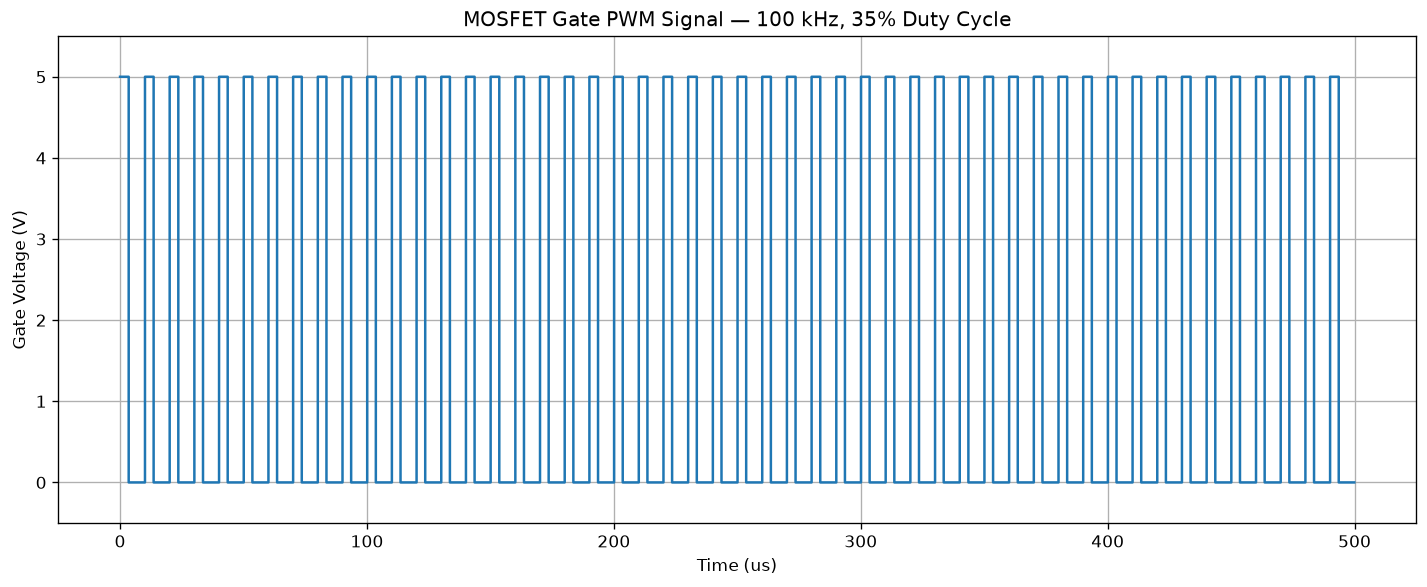

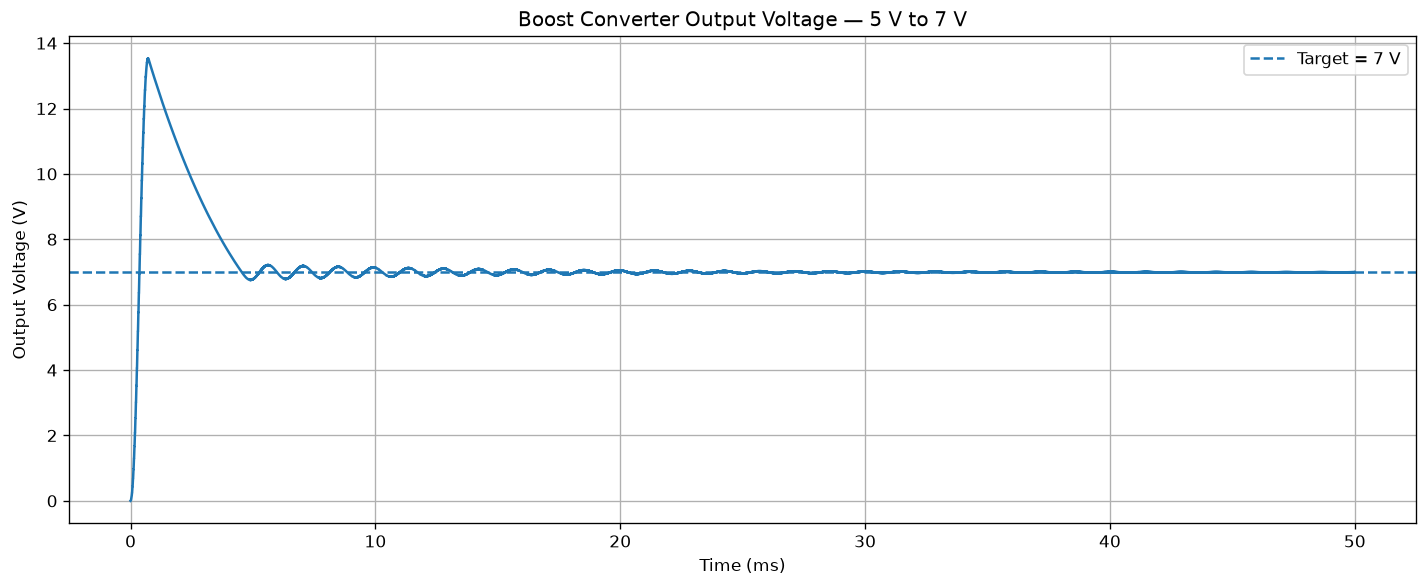

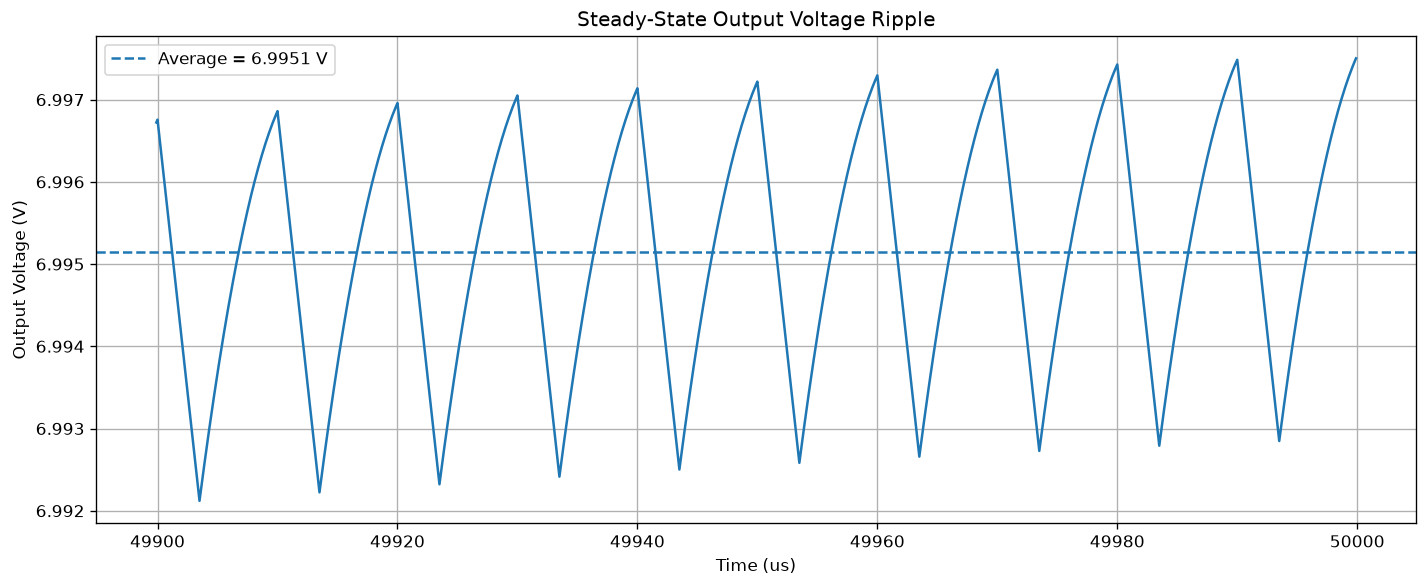

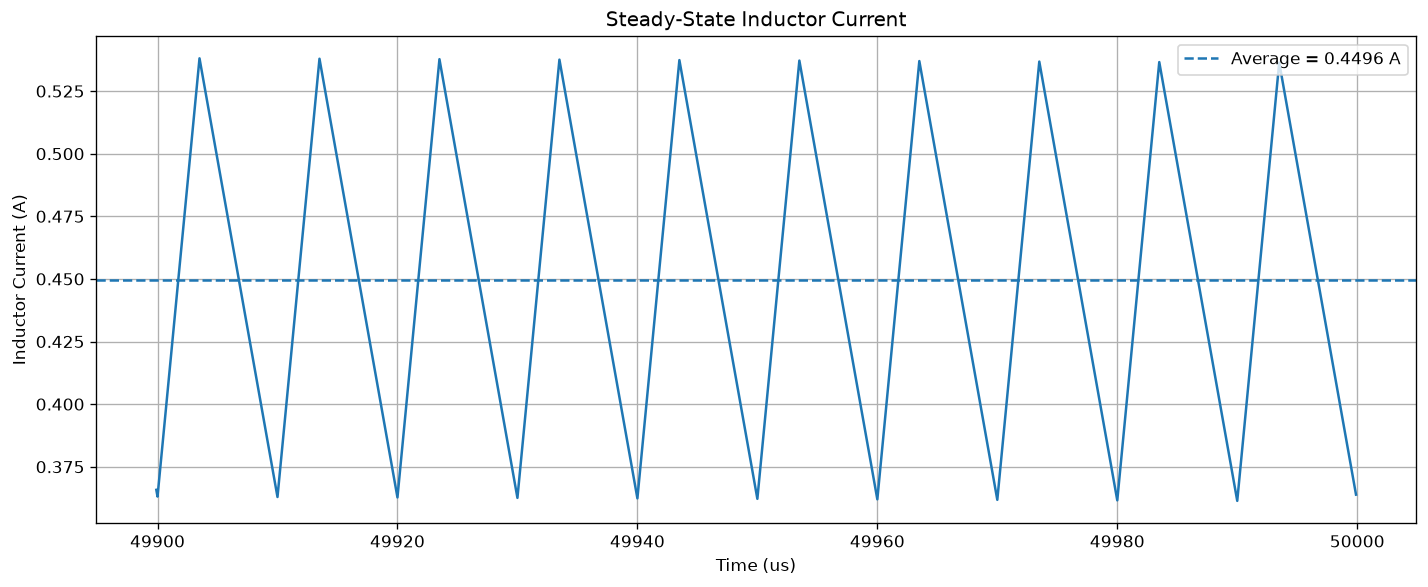

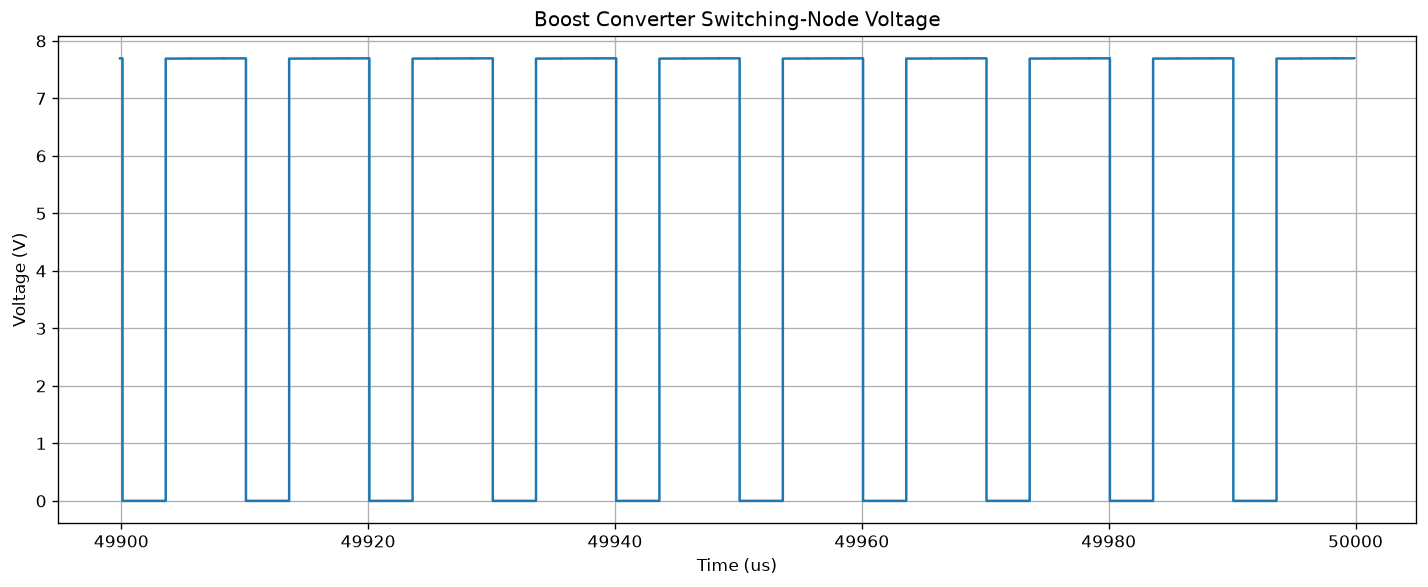

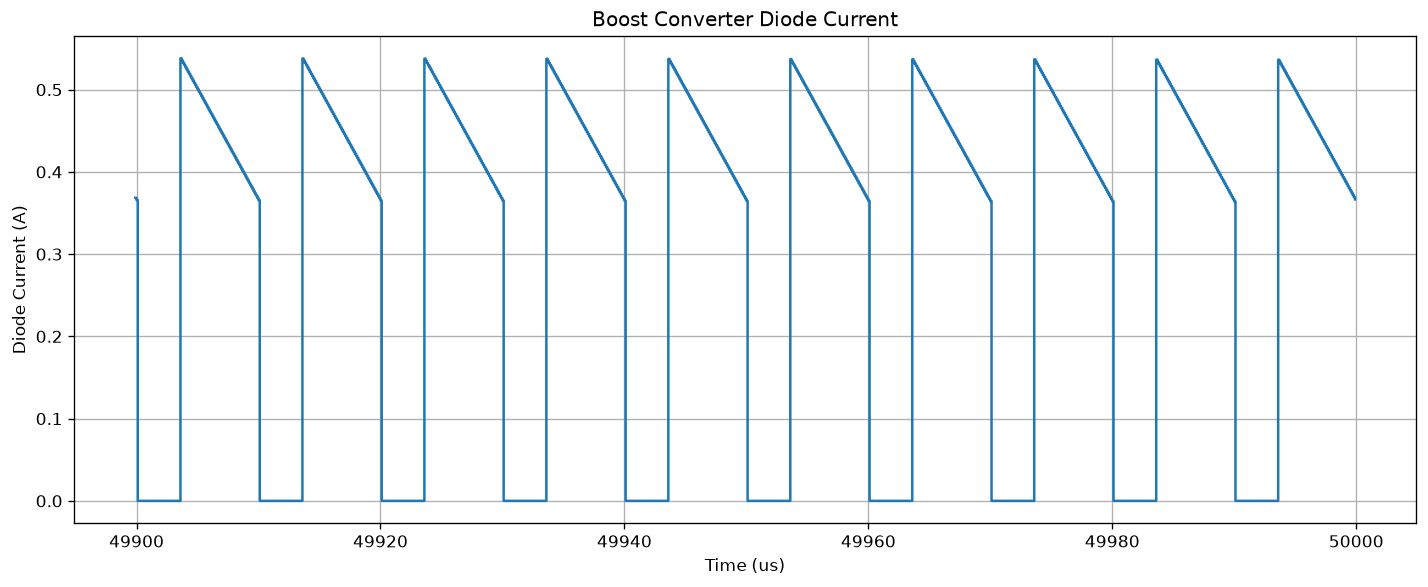

Six baseline figures saved successfully.


In [6]:
time = baseline_data["Time_s"].to_numpy()
gate = baseline_data["Gate_V"].to_numpy()
vout = baseline_data["Output_Voltage_V"].to_numpy()
il = baseline_data["Inductor_Current_A"].to_numpy()
sw = baseline_data["Switching_Node_V"].to_numpy()
diode = baseline_data["Diode_Current_A"].to_numpy()

period = 1 / BASE_FREQUENCY

mask = (
    time >=
    time[-1] - 10 * period
)

# ============================================================
# FIGURE 1 — PWM
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    time[:5000] * 1e6,
    gate[:5000],
    drawstyle="steps-post"
)

plt.xlabel("Time (us)")
plt.ylabel("Gate Voltage (V)")
plt.title(
    "MOSFET Gate PWM Signal — 100 kHz, 35% Duty Cycle"
)

plt.ylim(-0.5, 5.5)
plt.grid(True)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "Figure_01_PWM_Gate_Signal.png",
    dpi=300
)

plt.show()
plt.close()


# ============================================================
# FIGURE 2 — OUTPUT VOLTAGE TRANSIENT
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    time * 1000,
    vout
)

plt.axhline(
    7.0,
    linestyle="--",
    label="Target = 7 V"
)

plt.xlabel("Time (ms)")
plt.ylabel("Output Voltage (V)")
plt.title(
    "Boost Converter Output Voltage — 5 V to 7 V"
)

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "Figure_02_Output_Voltage_Transient.png",
    dpi=300
)

plt.show()
plt.close()


# ============================================================
# FIGURE 3 — OUTPUT RIPPLE
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    time[mask] * 1e6,
    vout[mask]
)

plt.axhline(
    np.mean(vout[mask]),
    linestyle="--",
    label=(
        f"Average = "
        f"{np.mean(vout[mask]):.4f} V"
    )
)

plt.xlabel("Time (us)")
plt.ylabel("Output Voltage (V)")
plt.title(
    "Steady-State Output Voltage Ripple"
)

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "Figure_03_Output_Voltage_Ripple.png",
    dpi=300
)

plt.show()
plt.close()


# ============================================================
# FIGURE 4 — INDUCTOR CURRENT
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    time[mask] * 1e6,
    il[mask]
)

plt.axhline(
    np.mean(il[mask]),
    linestyle="--",
    label=(
        f"Average = "
        f"{np.mean(il[mask]):.4f} A"
    )
)

plt.xlabel("Time (us)")
plt.ylabel("Inductor Current (A)")
plt.title(
    "Steady-State Inductor Current"
)

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "Figure_04_Inductor_Current.png",
    dpi=300
)

plt.show()
plt.close()


# ============================================================
# FIGURE 5 — SWITCHING NODE
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    time[mask] * 1e6,
    sw[mask],
    drawstyle="steps-post"
)

plt.xlabel("Time (us)")
plt.ylabel("Voltage (V)")
plt.title(
    "Boost Converter Switching-Node Voltage"
)

plt.grid(True)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "Figure_05_Switching_Node_Voltage.png",
    dpi=300
)

plt.show()
plt.close()


# ============================================================
# FIGURE 6 — DIODE CURRENT
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    time[mask] * 1e6,
    diode[mask],
    drawstyle="steps-post"
)

plt.xlabel("Time (us)")
plt.ylabel("Diode Current (A)")
plt.title(
    "Boost Converter Diode Current"
)

plt.grid(True)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "Figure_06_Diode_Current.png",
    dpi=300
)

plt.show()
plt.close()

print("Six baseline figures saved successfully.")

In [7]:
duty_values = np.array([
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60
])

rows = []

for duty in duty_values:

    data = simulate_boost(
        frequency=BASE_FREQUENCY,
        duty=duty,
        inductance=BASE_L,
        capacitance=BASE_C,
        load_resistance=BASE_RLOAD,
        simulation_time=BASE_SIMULATION_TIME,
        dt=BASE_DT
    )

    m = steady_state_metrics(data)

    ideal = (
        VIN /
        (1 - duty)
    )

    practical = (
        ideal -
        VF
    )

    ideal_error = (
        abs(
            m["Average_Vout_V"]
            - ideal
        )
        / ideal
        * 100
    )

    practical_error = (
        abs(
            m["Average_Vout_V"]
            - practical
        )
        / practical
        * 100
    )

    rows.append({

        "Duty_Cycle_percent":
            duty * 100,

        "Average_Vout_V":
            m["Average_Vout_V"],

        "Minimum_Vout_V":
            m["Minimum_Vout_V"],

        "Maximum_Vout_V":
            m["Maximum_Vout_V"],

        "Ripple_V":
            m["Output_Ripple_V"],

        "Output_Current_A":
            m["Output_Current_A"],

        "Output_Power_W":
            m["Output_Power_W"],

        "Ideal_Theory_Vout_V":
            ideal,

        "Practical_Theory_Vout_V":
            practical,

        "Percentage_Error":
            ideal_error,

        "Practical_Percentage_Error":
            practical_error
    })


duty_results = pd.DataFrame(rows)

duty_results.to_csv(
    DATASET_DIR /
    "Duty_Cycle_Parametric_Study.csv",
    index=False
)

display(duty_results)

,Duty_Cycle_percent,Average_Vout_V,Minimum_Vout_V,Maximum_Vout_V,Ripple_V,Output_Current_A,Output_Power_W,Ideal_Theory_Vout_V,Practical_Theory_Vout_V,Percentage_Error,Practical_Percentage_Error
0,20.0,5.550056,5.543195,5.556529,0.013334,0.231252,1.283464,6.250000,5.550000,11.199097,0.001017
1,25.0,5.966664,5.958766,5.974263,0.015497,0.248611,1.483379,6.666667,5.966667,10.500033,0.000036
2,30.0,6.442875,6.433587,6.451839,0.018253,0.268453,1.729610,7.142857,6.442857,9.799754,0.000273
3,35.0,6.992203,6.981307,7.003095,0.021789,0.291342,2.037121,7.692308,6.992308,9.101356,0.001492
4,40.0,7.633163,7.620115,7.646112,0.025997,0.318048,2.427716,8.333333,7.633333,8.402047,0.002235
5,45.0,8.390551,8.374795,8.405300,0.030506,0.349606,2.933390,9.090909,8.390909,7.703934,0.004262
6,50.0,9.299359,9.280017,9.317955,0.037938,0.387473,3.603253,10.000000,9.300000,7.006414,0.006897
7,55.0,10.410444,10.385818,10.433921,0.048103,0.433768,4.515723,11.111111,10.411111,6.306005,0.006409
8,60.0,11.798777,11.767154,11.829619,0.062465,0.491616,5.800464,12.500000,11.800000,5.609786,0.010366


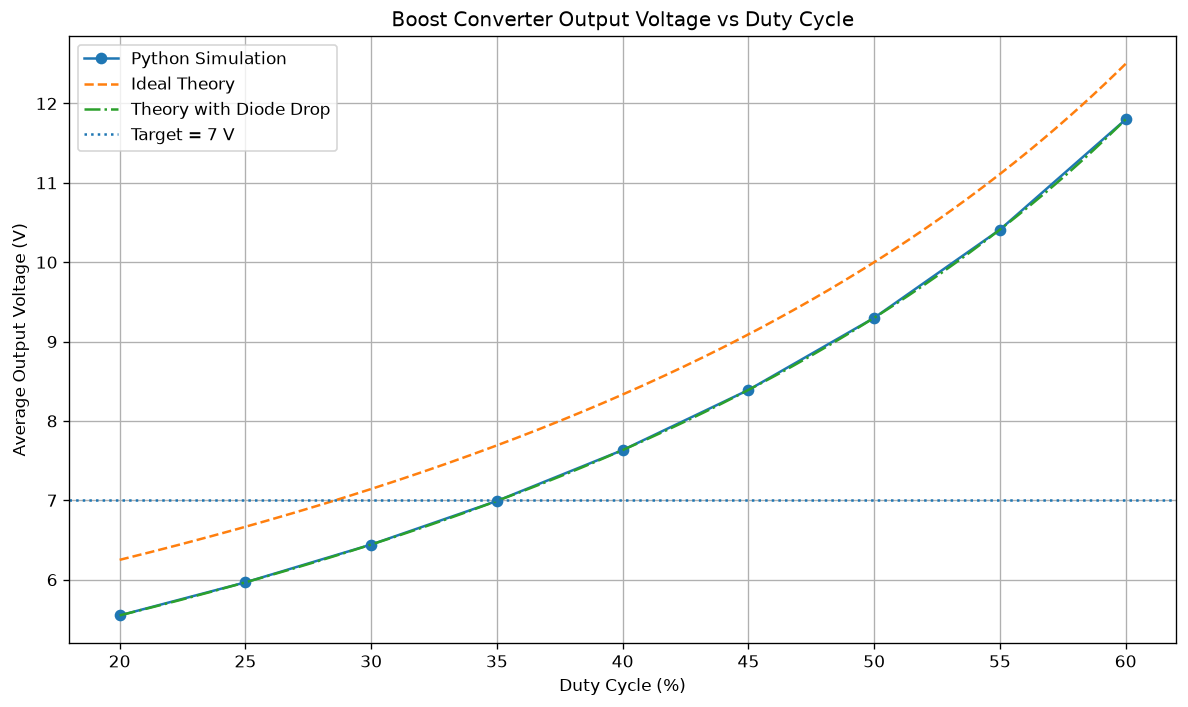

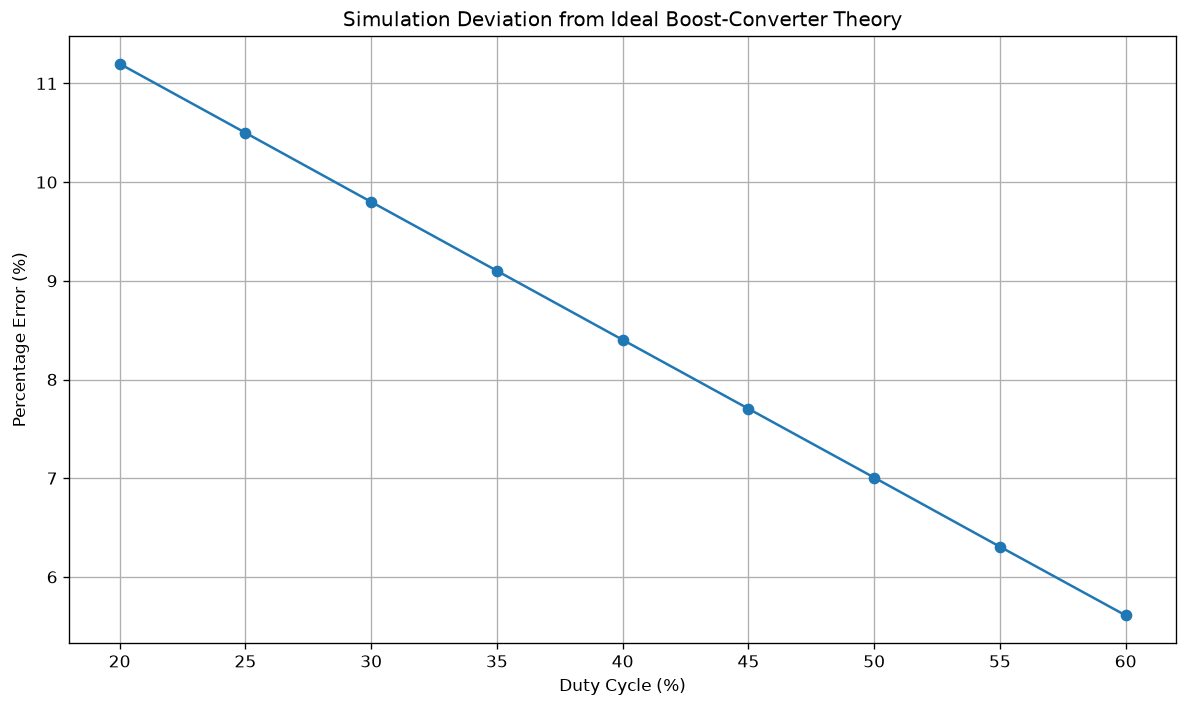

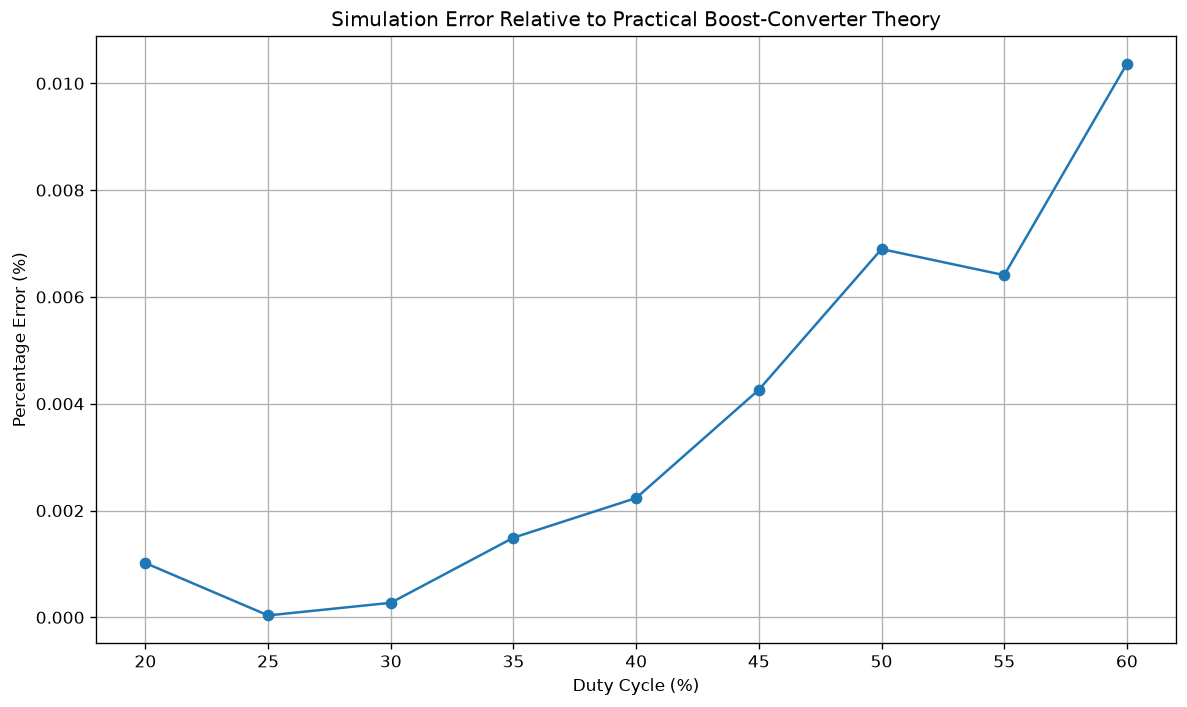

Duty-cycle figures saved successfully.


In [8]:
D = (
    duty_results["Duty_Cycle_percent"]
    .to_numpy()
    / 100
)

D_curve = np.linspace(
    0.20,
    0.60,
    400
)

# ============================================================
# FIGURE 7
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    duty_results["Duty_Cycle_percent"],
    duty_results["Average_Vout_V"],
    marker="o",
    label="Python Simulation"
)

plt.plot(
    D_curve * 100,
    VIN / (1 - D_curve),
    linestyle="--",
    label="Ideal Theory"
)

plt.plot(
    D_curve * 100,
    VIN / (1 - D_curve) - VF,
    linestyle="-.",
    label="Theory with Diode Drop"
)

plt.axhline(
    7,
    linestyle=":",
    label="Target = 7 V"
)

plt.xlabel("Duty Cycle (%)")
plt.ylabel("Average Output Voltage (V)")
plt.title(
    "Boost Converter Output Voltage vs Duty Cycle"
)

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "Figure_07_Output_Voltage_vs_Duty_Cycle.png",
    dpi=300
)

plt.show()
plt.close()


# ============================================================
# FIGURE 8
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    duty_results["Duty_Cycle_percent"],
    duty_results["Percentage_Error"],
    marker="o"
)

plt.xlabel("Duty Cycle (%)")
plt.ylabel("Percentage Error (%)")
plt.title(
    "Simulation Deviation from Ideal Boost-Converter Theory"
)

plt.grid(True)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "Figure_08_Ideal_Theory_Error.png",
    dpi=300
)

plt.show()
plt.close()


# ============================================================
# FIGURE 9
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    duty_results["Duty_Cycle_percent"],
    duty_results["Practical_Percentage_Error"],
    marker="o"
)

plt.xlabel("Duty Cycle (%)")
plt.ylabel("Percentage Error (%)")

plt.title(
    "Simulation Error Relative to Practical Boost-Converter Theory"
)

plt.grid(True)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "Figure_09_Practical_Theory_Error.png",
    dpi=300
)

plt.show()
plt.close()

print("Duty-cycle figures saved successfully.")

,Inductor_uH,Average_Vout_V,Output_Ripple_V,Average_IL_A,Minimum_IL_A,Maximum_IL_A,Inductor_Ripple_A
0,47,6.992058,0.014056,0.445203,0.248971,0.641160,0.392189
1,68,6.991987,0.017190,0.446014,0.305598,0.586158,0.280560
2,100,6.992203,0.021789,0.446678,0.346638,0.546232,0.199594
3,150,6.992182,0.026656,0.447779,0.376710,0.518955,0.142244
4,220,6.992557,0.031890,0.447103,0.394230,0.499675,0.105445
5,330,6.992901,0.037860,0.447597,0.407776,0.489541,0.081765


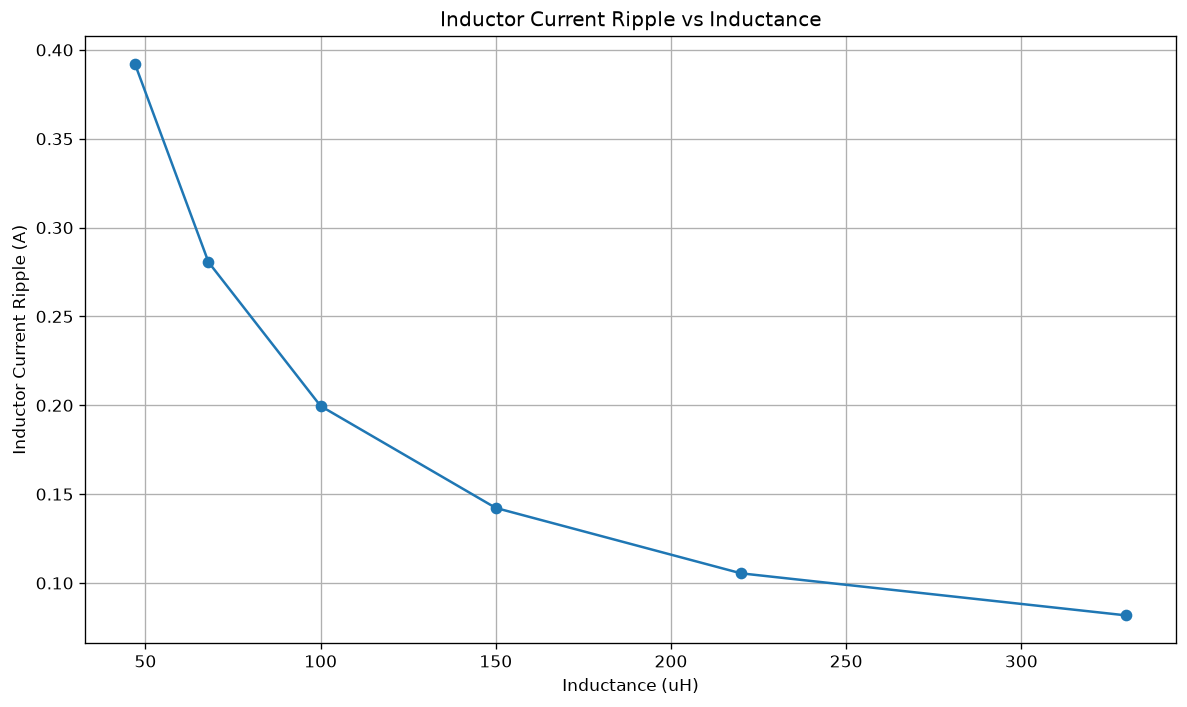

In [9]:
values_uH = np.array([
    47,
    68,
    100,
    150,
    220,
    330
])

rows = []

for value_uH in values_uH:

    data = simulate_boost(
        frequency=BASE_FREQUENCY,
        duty=BASE_DUTY,
        inductance=value_uH * 1e-6,
        capacitance=BASE_C,
        load_resistance=BASE_RLOAD,
        simulation_time=BASE_SIMULATION_TIME,
        dt=BASE_DT
    )

    m = steady_state_metrics(data)

    rows.append({

        "Inductor_uH":
            value_uH,

        "Average_Vout_V":
            m["Average_Vout_V"],

        "Output_Ripple_V":
            m["Output_Ripple_V"],

        "Average_IL_A":
            m["Average_IL_A"],

        "Minimum_IL_A":
            m["Minimum_IL_A"],

        "Maximum_IL_A":
            m["Maximum_IL_A"],

        "Inductor_Ripple_A":
            m["Inductor_Ripple_A"]
    })


inductance_results = pd.DataFrame(rows)

inductance_results.to_csv(
    DATASET_DIR /
    "Inductance_Parametric_Study.csv",
    index=False
)

display(inductance_results)


# Plot
plt.figure(figsize=(10, 6))

plt.plot(
    inductance_results["Inductor_uH"],
    inductance_results["Inductor_Ripple_A"],
    marker="o"
)

plt.xlabel("Inductance (uH)")
plt.ylabel("Inductor Current Ripple (A)")

plt.title(
    "Inductor Current Ripple vs Inductance"
)

plt.grid(True)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "Figure_10_Inductor_Ripple_vs_Inductance.png",
    dpi=300
)

plt.show()
plt.close()

,Capacitor_uF,Average_Vout_V,Minimum_Vout_V,Maximum_Vout_V,Switching_Ripple_V,Switching_Ripple_mV
0,47,6.991763,6.979602,7.001293,0.021691,21.691162
1,100,6.992051,6.986189,6.996670,0.010196,10.196035
2,220,6.992203,6.981307,7.003095,0.004678,4.677915
3,470,6.992504,6.949937,7.036242,0.002753,2.753320


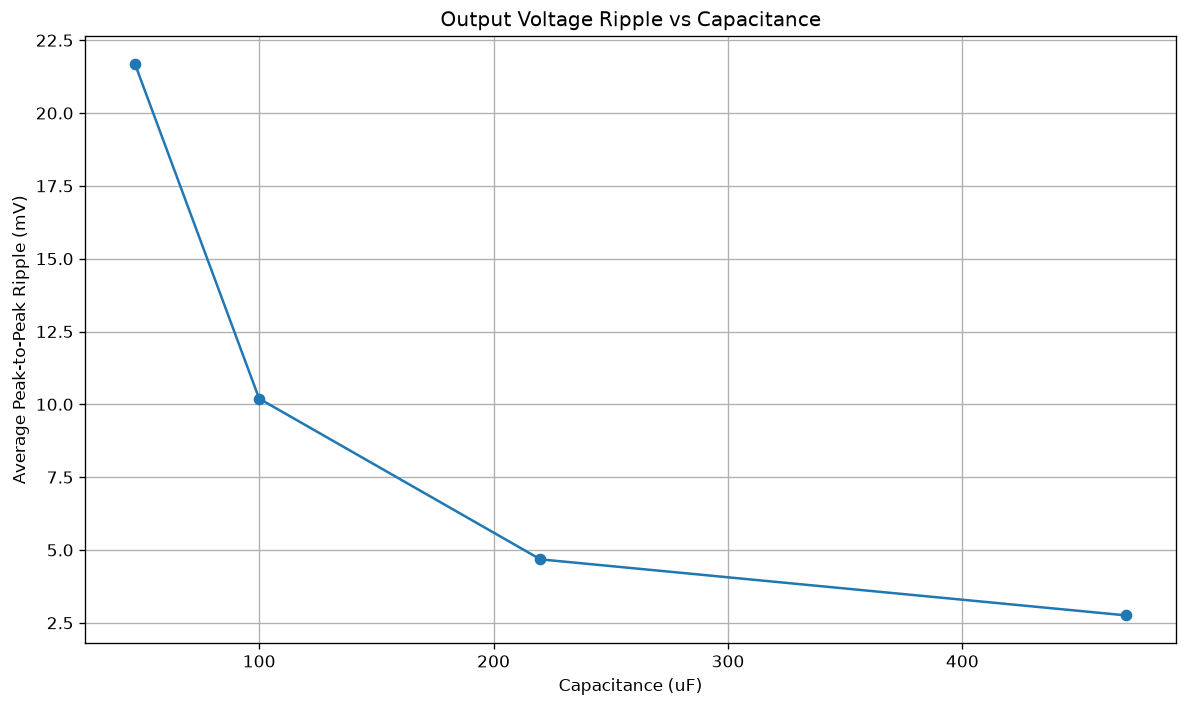

In [10]:
values_uF = np.array([
    47,
    100,
    220,
    470
])

rows = []

for value_uF in values_uF:

    data = simulate_boost(
        frequency=BASE_FREQUENCY,
        duty=BASE_DUTY,
        inductance=BASE_L,
        capacitance=value_uF * 1e-6,
        load_resistance=BASE_RLOAD,
        simulation_time=BASE_SIMULATION_TIME,
        dt=BASE_DT
    )

    m = steady_state_metrics(data)

    ripple = switching_cycle_ripple(
        data,
        BASE_FREQUENCY,
        number_of_cycles=10
    )

    rows.append({

        "Capacitor_uF":
            value_uF,

        "Average_Vout_V":
            m["Average_Vout_V"],

        "Minimum_Vout_V":
            m["Minimum_Vout_V"],

        "Maximum_Vout_V":
            m["Maximum_Vout_V"],

        "Switching_Ripple_V":
            ripple,

        "Switching_Ripple_mV":
            ripple * 1000
    })


capacitance_results = pd.DataFrame(rows)

capacitance_results.to_csv(
    DATASET_DIR /
    "Final_Capacitance_Ripple_Study.csv",
    index=False
)

display(capacitance_results)


plt.figure(figsize=(10, 6))

plt.plot(
    capacitance_results["Capacitor_uF"],
    capacitance_results["Switching_Ripple_mV"],
    marker="o"
)

plt.xlabel("Capacitance (uF)")
plt.ylabel(
    "Average Peak-to-Peak Ripple (mV)"
)

plt.title(
    "Output Voltage Ripple vs Capacitance"
)

plt.grid(True)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "Figure_11_Output_Ripple_vs_Capacitance.png",
    dpi=300
)

plt.show()
plt.close()

In [11]:
values_ohm = np.array([
    10,
    15,
    22,
    27,
    33,
    47,
    68
])

rows = []

for value_ohm in values_ohm:

    data = simulate_boost(
        frequency=BASE_FREQUENCY,
        duty=BASE_DUTY,
        inductance=BASE_L,
        capacitance=BASE_C,
        load_resistance=float(value_ohm),
        simulation_time=BASE_SIMULATION_TIME,
        dt=BASE_DT
    )

    period = 1 / BASE_FREQUENCY

    samples_per_cycle = int(
        period / BASE_DT
    )

    v = data[
        "Output_Voltage_V"
    ].to_numpy()[
        -10 * samples_per_cycle:
    ]

    il = data[
        "Inductor_Current_A"
    ].to_numpy()[
        -10 * samples_per_cycle:
    ]

    vavg = float(
        np.mean(v)
    )

    vmin = float(
        np.min(v)
    )

    vmax = float(
        np.max(v)
    )

    ripple = vmax - vmin

    output_current = (
        vavg /
        value_ohm
    )

    output_power = (
        vavg *
        output_current
    )

    rows.append({

        "Load_Resistance_Ohm":
            value_ohm,

        "Average_Vout_V":
            vavg,

        "Minimum_Vout_V":
            vmin,

        "Maximum_Vout_V":
            vmax,

        "Output_Ripple_V":
            ripple,

        "Output_Current_A":
            output_current,

        "Output_Power_W":
            output_power,

        "Average_Inductor_Current_A":
            float(np.mean(il))
    })


load_results = pd.DataFrame(rows)

load_results.to_csv(
    DATASET_DIR /
    "Load_Resistance_Parametric_Study.csv",
    index=False
)

display(load_results)

,Load_Resistance_Ohm,Average_Vout_V,Minimum_Vout_V,Maximum_Vout_V,Output_Ripple_V,Output_Current_A,Output_Power_W,Average_Inductor_Current_A
0,10,6.992228,6.986384,6.997510,0.011125,0.699223,4.889125,1.074367
1,15,6.992578,6.988585,6.996009,0.007423,0.466172,3.259744,0.715819
2,22,6.993548,6.990330,6.996238,0.005909,0.317889,2.223169,0.484480
3,27,6.987186,6.984719,6.989239,0.004520,0.258785,1.808176,0.398169
4,33,6.990969,6.987270,6.994249,0.006980,0.211848,1.481019,0.336835
5,47,6.985862,6.981865,6.989680,0.007815,0.148635,1.038346,0.245721
6,68,7.006265,7.003922,7.007742,0.003820,0.103033,0.721879,0.164455


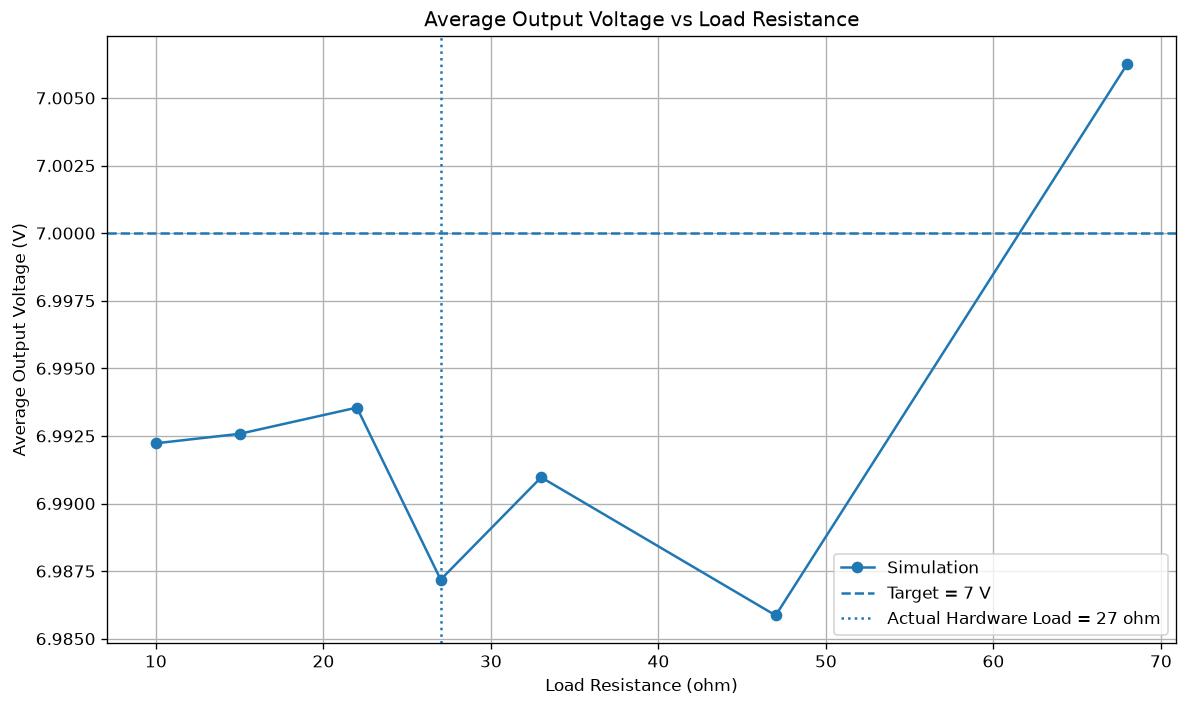

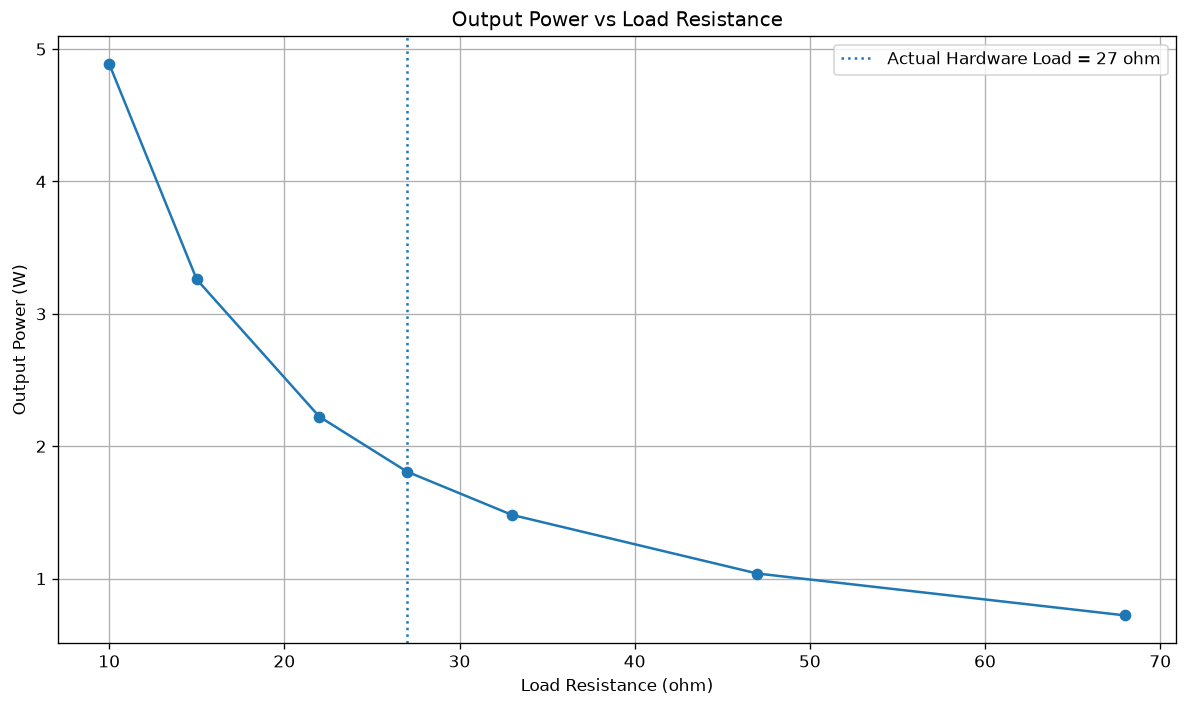

Load-study figures saved successfully.


In [12]:
# ============================================================
# FIGURE 12 — OUTPUT VOLTAGE VS LOAD
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    load_results["Load_Resistance_Ohm"],
    load_results["Average_Vout_V"],
    marker="o",
    label="Simulation"
)

plt.axhline(
    7.0,
    linestyle="--",
    label="Target = 7 V"
)

plt.axvline(
    HARDWARE_RLOAD,
    linestyle=":",
    label="Actual Hardware Load = 27 ohm"
)

plt.xlabel("Load Resistance (ohm)")
plt.ylabel("Average Output Voltage (V)")

plt.title(
    "Average Output Voltage vs Load Resistance"
)

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "Figure_12_Output_Voltage_vs_Load.png",
    dpi=300
)

plt.show()
plt.close()


# ============================================================
# FIGURE 13 — OUTPUT POWER VS LOAD
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    load_results["Load_Resistance_Ohm"],
    load_results["Output_Power_W"],
    marker="o"
)

plt.axvline(
    HARDWARE_RLOAD,
    linestyle=":",
    label="Actual Hardware Load = 27 ohm"
)

plt.xlabel("Load Resistance (ohm)")
plt.ylabel("Output Power (W)")

plt.title(
    "Output Power vs Load Resistance"
)

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "Figure_13_Output_Power_vs_Load.png",
    dpi=300
)

plt.show()
plt.close()

print("Load-study figures saved successfully.")

In [13]:
values_kHz = np.array([
    50,
    75,
    100,
    150,
    200
])

rows = []

for value_kHz in values_kHz:

    frequency = (
        value_kHz *
        1000.0
    )

    # 50 ns is used for this sweep
    # to maintain adequate switching resolution.
    dt = 50e-9

    data = simulate_boost(
        frequency=frequency,
        duty=BASE_DUTY,
        inductance=BASE_L,
        capacitance=BASE_C,
        load_resistance=BASE_RLOAD,
        simulation_time=0.03,
        dt=dt
    )

    period = 1 / frequency

    samples_per_cycle = int(
        period / dt
    )

    v = data[
        "Output_Voltage_V"
    ].to_numpy()[
        -10 * samples_per_cycle:
    ]

    il = data[
        "Inductor_Current_A"
    ].to_numpy()[
        -10 * samples_per_cycle:
    ]

    rows.append({

        "Frequency_kHz":
            value_kHz,

        "Average_Vout_V":
            float(np.mean(v)),

        "Minimum_Vout_V":
            float(np.min(v)),

        "Maximum_Vout_V":
            float(np.max(v)),

        "Output_Ripple_V":
            float(
                np.max(v) -
                np.min(v)
            ),

        "Average_IL_A":
            float(np.mean(il)),

        "Inductor_Ripple_A":
            float(
                np.max(il) -
                np.min(il)
            )
    })


frequency_results = pd.DataFrame(rows)

frequency_results.to_csv(
    DATASET_DIR /
    "Switching_Frequency_Parametric_Study.csv",
    index=False
)

display(frequency_results)

,Frequency_kHz,Average_Vout_V,Minimum_Vout_V,Maximum_Vout_V,Output_Ripple_V,Average_IL_A,Inductor_Ripple_A
0,50,6.980733,6.969952,6.991011,0.021059,0.466518,0.363375
1,75,7.005930,6.998062,7.012466,0.014403,0.469951,0.243587
2,100,7.013861,7.010116,7.016432,0.006316,0.454723,0.187757
3,150,7.016960,7.014235,7.019064,0.004829,0.438506,0.131738
4,200,7.011609,7.008917,7.014270,0.005354,0.425808,0.093186


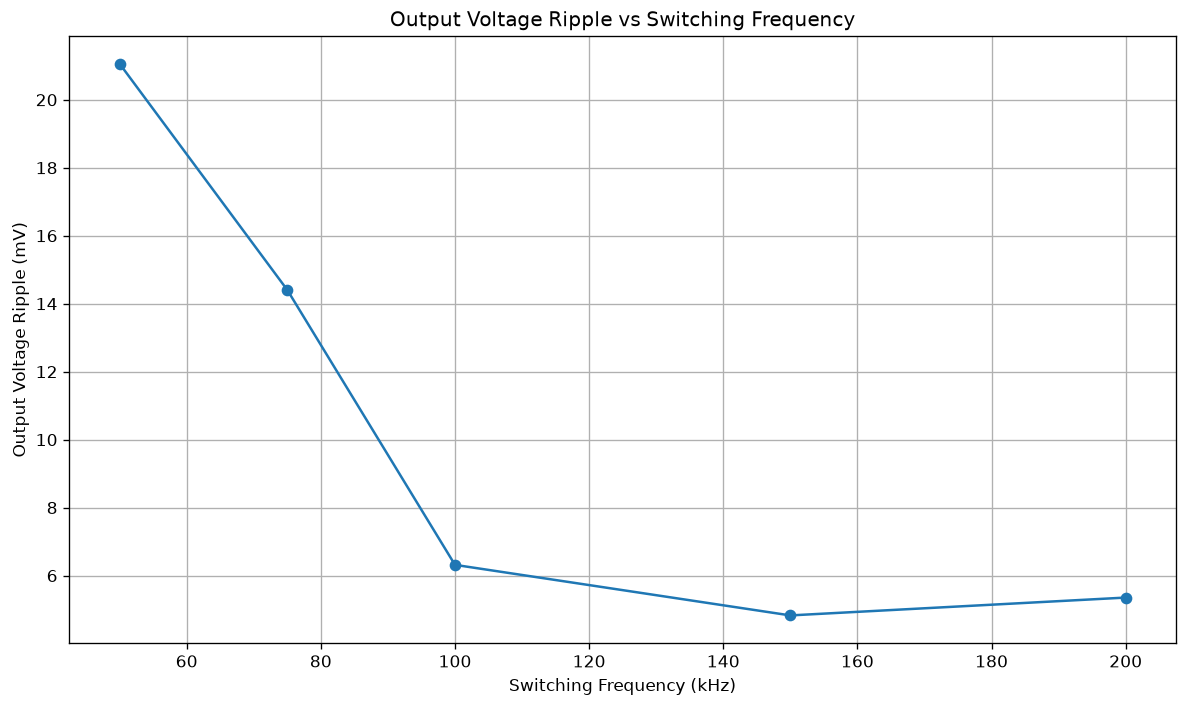

ALL SIMULATIONS COMPLETE

Datasets:
C:\Users\R N V SAI NANDAN\BOOST_SIMULATIONS_FINAL\results\datasets

Figures:
C:\Users\R N V SAI NANDAN\BOOST_SIMULATIONS_FINAL\results\figures

Summary:
C:\Users\R N V SAI NANDAN\BOOST_SIMULATIONS_FINAL\results\summary

Paper-ready figures:
 - Figure_01_PWM_Gate_Signal.png
 - Figure_02_Output_Voltage_Transient.png
 - Figure_03_Output_Voltage_Ripple.png
 - Figure_04_Inductor_Current.png
 - Figure_05_Switching_Node_Voltage.png
 - Figure_06_Diode_Current.png
 - Figure_07_Output_Voltage_vs_Duty_Cycle.png
 - Figure_08_Ideal_Theory_Error.png
 - Figure_09_Practical_Theory_Error.png
 - Figure_10_Inductor_Ripple_vs_Inductance.png
 - Figure_11_Output_Ripple_vs_Capacitance.png
 - Figure_12_Output_Voltage_vs_Load.png
 - Figure_13_Output_Power_vs_Load.png
 - Figure_14_Output_Ripple_vs_Frequency.png


In [14]:
# ============================================================
# FIGURE 14 — OUTPUT RIPPLE VS FREQUENCY
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    frequency_results["Frequency_kHz"],
    frequency_results["Output_Ripple_V"] * 1000,
    marker="o"
)

plt.xlabel(
    "Switching Frequency (kHz)"
)

plt.ylabel(
    "Output Voltage Ripple (mV)"
)

plt.title(
    "Output Voltage Ripple vs Switching Frequency"
)

plt.grid(True)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "Figure_14_Output_Ripple_vs_Frequency.png",
    dpi=300
)

plt.show()
plt.close()


# ============================================================
# PROJECT PARAMETERS FILE
# ============================================================

project_parameters = pd.DataFrame({

    "Parameter": [

        "Input voltage",
        "Target output voltage",
        "Baseline switching frequency",
        "Baseline duty cycle",
        "Baseline inductance",
        "Baseline capacitance",
        "Simulation baseline load",
        "Actual hardware load",
        "Diode forward-drop approximation",
        "Baseline simulation time",
        "Baseline time step"
    ],

    "Value": [

        "5 V",
        "7 V",
        "100 kHz",
        "35 %",
        "100 uH",
        "220 uF",
        "24 ohm",
        "27 ohm",
        "0.7 V",
        "50 ms",
        "100 ns"
    ]
})

project_parameters.to_csv(
    SUMMARY_DIR /
    "Project_Parameters.csv",
    index=False
)


print("=" * 70)
print("ALL SIMULATIONS COMPLETE")
print("=" * 70)

print("\nDatasets:")
print(DATASET_DIR)

print("\nFigures:")
print(FIGURE_DIR)

print("\nSummary:")
print(SUMMARY_DIR)

print("\nPaper-ready figures:")

for p in sorted(
    FIGURE_DIR.glob("*.png")
):

    print(
        " -",
        p.name
    )

In [15]:
# ============================================================
# AUTOMATIC FINAL CONSISTENCY CHECK
# ============================================================

required_datasets = [

    "Boost_Converter_5V_to_7V_Python_Simulation.csv",

    "Duty_Cycle_Parametric_Study.csv",

    "Inductance_Parametric_Study.csv",

    "Final_Capacitance_Ripple_Study.csv",

    "Load_Resistance_Parametric_Study.csv",

    "Switching_Frequency_Parametric_Study.csv"
]


required_figure_prefixes = [

    f"Figure_{i:02d}_"
    for i in range(1, 15)
]


# Check datasets
missing_datasets = [

    filename
    for filename in required_datasets

    if not (
        DATASET_DIR /
        filename
    ).exists()
]


# Check figures
missing_figures = [

    prefix
    for prefix in required_figure_prefixes

    if not any(
        p.name.startswith(prefix)
        for p in FIGURE_DIR.glob("*.png")
    )
]


# Assertions
assert not missing_datasets, (
    f"Missing datasets: {missing_datasets}"
)

assert not missing_figures, (
    f"Missing figures: {missing_figures}"
)

assert abs(
    metrics["Average_Vout_V"] - 7.0
) < 0.05, (
    "Baseline output is outside "
    "the expected 5 V to 7 V design range."
)

assert (
    0 <
    metrics["Output_Ripple_V"] <
    0.1
), (
    "Baseline ripple is outside "
    "the expected range."
)

assert (
    len(baseline_data) ==
    500000
), (
    "Unexpected baseline sample count."
)


# Final message
print("=" * 70)
print("                 FINAL CHECK: PASSED")
print("=" * 70)

print(
    f"\nBaseline average Vout : "
    f"{metrics['Average_Vout_V']:.6f} V"
)

print(
    f"Baseline ripple       : "
    f"{metrics['Output_Ripple_V']*1000:.3f} mV"
)

print(
    f"Output power          : "
    f"{metrics['Output_Power_W']:.6f} W"
)

print(
    f"Practical theory error: "
    f"{practical_error:.6f} %"
)

print(
    f"\nDatasets generated    : "
    f"{len(required_datasets)}"
)

print(
    f"Figures generated     : "
    f"{len(required_figure_prefixes)}"
)

print(
    "\nPASS — all required datasets and figures exist."
)

print(
    "The simulation run is complete."
)

                 FINAL CHECK: PASSED

Baseline average Vout : 6.992203 V
Baseline ripple       : 21.789 mV
Output power          : 2.037121 W
Practical theory error: 0.010366 %

Datasets generated    : 6
Figures generated     : 14

PASS — all required datasets and figures exist.
The simulation run is complete.
